In [2]:
import json
with open("query_dict.json", 'r') as file:
    query_dict = json.load(file)
with open("response_dict.json", 'r') as file:
    response_dict = json.load(file)
with open("extracted_code.json", 'r') as file:
    code_dict = json.load(file)

# TODO
- [ ] I am not sure whether the core API is correct for the query purpose. It worth computing how many wrong core API are used. If this number is large, it supports the claim that RAG of API retrieval in biomania is worthy.

# scanpy:1 [done]
* check try 3
---
* new report
* plans: load data -> preprocess -> SCVI model -> vis.
* error: pre-processed datasets (following unnecessary preprocessing). Applying scvi to preprocessed data is not desired, and lead to nan bug.

---
* original report
* plans: load data -> preprocess -> scanpy.external.pp.harmony_integrate() -> vis.
* error: pre-processed datasets (which potentially have been processed by log1p) containing negative values. log1p applying to them generates nan.



## results

In [2]:
print(query_dict['scanpy:1'])

Provide the python code for batch correction with the API only from Scanpy. Apply it to the built-in pbmc3k processed dataset and pbmc68k reduced dataset.


In [11]:
print(response_dict['scanpy:1'])

To perform batch correction using Scanpy, we'll first load the built-in datasets, combine them, and then utilize Scanpy’s tools to preprocess and integrate the datasets. For this example, we'll use the `pbmc3k_processed` and `pbmc68k_reduced` datasets. Note that Scanpy doesn't directly support batch correction in the same way as specialized tools like `Harmony` or `ComBat`, but uses integration methods such as canonical correlation analysis (CCA) provided through an integration with the `scVI-tools` library.

Please ensure that Scanpy and scVI-tools (for handling the dataset integration and batch correction) are installed in your Python environment. You can install them using the following commands if they are not already installed:

```bash
pip install scanpy
pip install scvi-tools
```

Here is a step-by-step guide and Python code to apply batch correction using Scanpy with these datasets:

1. **Import Necessary Libraries**:
```python
import scanpy as sc
import scvi
import numpy as np

In [4]:
print(code_dict['scanpy:1'])

import scanpy as sc
import scvi
import numpy as np
# Normally, you would load datasets from files or from Scanpy's dataset functions:
# adata_pbmc3k = sc.datasets.pbmc3k_processed()    # Adjust this line as needed.
# adata_pbmc68k = sc.datasets.pbmc68k_reduced()   # Adjust this line as needed.
# Simulate data load:
adata_pbmc3k = sc.datasets.pbmc3k()
adata_pbmc68k = sc.datasets.pbmc68k()
sc.pp.normalize_total(adata_pbmc3k, target_sum=1e4)
sc.pp.log1p(adata_pbmc3k)

sc.pp.normalize_total(adata_pbmc68k, target_sum=1e4)
sc.pp.log1p(adata_pbmc68k)
# Concatenate the datasets for integration.
adata = adata_pbmc3k.concatenate(adata_pbmc68k, batch_key="batch", batch_categories=["pbmc3k", "pbmc68k"])

# Prepare data for scVI, defining the batch as categorical
adata.layers["counts"] = adata.X.copy()  # Store the count data
scvi.data.setup_anndata(adata, layer="counts", batch_key="batch")
# Initialize and train the model
scvi_model = scvi.model.SCVI(adata)
scvi_model.train()

# Get the harmonized

## try 1
* this error can be simply solved by modifying comments, without the knowledge of biology, used packages and API.

In [6]:
import scanpy as sc
import scvi
import numpy as np
# Normally, you would load datasets from files or from Scanpy's dataset functions:
# adata_pbmc3k = sc.datasets.pbmc3k_processed()    # Adjust this line as needed.
# adata_pbmc68k = sc.datasets.pbmc68k_reduced()   # Adjust this line as needed.
# Simulate data load:
adata_pbmc3k = sc.datasets.pbmc3k()
adata_pbmc68k = sc.datasets.pbmc68k()
sc.pp.normalize_total(adata_pbmc3k, target_sum=1e4)
sc.pp.log1p(adata_pbmc3k)

sc.pp.normalize_total(adata_pbmc68k, target_sum=1e4)
sc.pp.log1p(adata_pbmc68k)
# Concatenate the datasets for integration.
adata = adata_pbmc3k.concatenate(adata_pbmc68k, batch_key="batch", batch_categories=["pbmc3k", "pbmc68k"])

# Prepare data for scVI, defining the batch as categorical
adata.layers["counts"] = adata.X.copy()  # Store the count data
scvi.data.setup_anndata(adata, layer="counts", batch_key="batch")
# Initialize and train the model
scvi_model = scvi.model.SCVI(adata)
scvi_model.train()

# Get the harmonized latent representation
latent = scvi_model.get_latent_representation()

# Update AnnData object with the corrected embedding
adata.obsm["X_scVI"] = latent
sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.umap(adata)
sc.tl.leiden(adata)
sc.pl.umap(adata, color=["leiden", "batch"])

AttributeError: module 'scanpy.datasets' has no attribute 'pbmc68k'

## try 2
* to revise this error, we need to check the most similar API in document

In [7]:
import scanpy as sc
import scvi
import numpy as np
# Normally, you would load datasets from files or from Scanpy's dataset functions:
adata_pbmc3k = sc.datasets.pbmc3k_processed()    # Adjust this line as needed.
adata_pbmc68k = sc.datasets.pbmc68k_reduced()   # Adjust this line as needed.
# Simulate data load:
# adata_pbmc3k = sc.datasets.pbmc3k()
# adata_pbmc68k = sc.datasets.pbmc68k()
sc.pp.normalize_total(adata_pbmc3k, target_sum=1e4)
sc.pp.log1p(adata_pbmc3k)

sc.pp.normalize_total(adata_pbmc68k, target_sum=1e4)
sc.pp.log1p(adata_pbmc68k)
# Concatenate the datasets for integration.
adata = adata_pbmc3k.concatenate(adata_pbmc68k, batch_key="batch", batch_categories=["pbmc3k", "pbmc68k"])

# Prepare data for scVI, defining the batch as categorical
adata.layers["counts"] = adata.X.copy()  # Store the count data
scvi.data.setup_anndata(adata, layer="counts", batch_key="batch")
# Initialize and train the model
scvi_model = scvi.model.SCVI(adata)
scvi_model.train()

# Get the harmonized latent representation
latent = scvi_model.get_latent_representation()

# Update AnnData object with the corrected embedding
adata.obsm["X_scVI"] = latent
sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.umap(adata)
sc.tl.leiden(adata)
sc.pl.umap(adata, color=["leiden", "batch"])

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:383: RuntimeWarning: invalid value encountered in log1p
  np.log1p(X, out=X)
/var/folders/_j/jhp4k00j0vx40wdvn_jv_jr40000gn/T/ipykernel_34971/2932911832.py:16: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_pbmc3k.concatenate(adata_pbmc68k, batch_key="batch", batch_categories=["pbmc3k", "pbmc68k"])


AttributeError: module 'scvi.data' has no attribute 'setup_anndata'

## try 3
* to resolve this error, gpt4 need to access document

In [8]:
import scanpy as sc
import scvi
import numpy as np
# Normally, you would load datasets from files or from Scanpy's dataset functions:
adata_pbmc3k = sc.datasets.pbmc3k_processed()    # Adjust this line as needed.
adata_pbmc68k = sc.datasets.pbmc68k_reduced()   # Adjust this line as needed.
# Simulate data load:
# adata_pbmc3k = sc.datasets.pbmc3k()
# adata_pbmc68k = sc.datasets.pbmc68k()
sc.pp.normalize_total(adata_pbmc3k, target_sum=1e4)
sc.pp.log1p(adata_pbmc3k)

sc.pp.normalize_total(adata_pbmc68k, target_sum=1e4)
sc.pp.log1p(adata_pbmc68k)
# Concatenate the datasets for integration.
adata = adata_pbmc3k.concatenate(adata_pbmc68k, batch_key="batch", batch_categories=["pbmc3k", "pbmc68k"])

# Prepare data for scVI, defining the batch as categorical
adata.layers["counts"] = adata.X.copy()  # Store the count data
scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="batch")
# Initialize and train the model
scvi_model = scvi.model.SCVI(adata)
scvi_model.train()

# Get the harmonized latent representation
latent = scvi_model.get_latent_representation()

# Update AnnData object with the corrected embedding
adata.obsm["X_scVI"] = latent
sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.umap(adata)
sc.tl.leiden(adata)
sc.pl.umap(adata, color=["leiden", "batch"])

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:383: RuntimeWarning: invalid value encountered in log1p
  np.log1p(X, out=X)
/var/folders/_j/jhp4k00j0vx40wdvn_jv_jr40000gn/T/ipykernel_34971/2909394875.py:16: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_pbmc3k.concatenate(adata_pbmc68k, batch_key="batch", batch_categories=["pbmc3k", "pbmc68k"])
/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(a

Training:   0%|          | 0/400 [00:00<?, ?it/s]

ValueError: Expected parameter loc (Tensor of shape (128, 10)) of distribution Normal(loc: torch.Size([128, 10]), scale: torch.Size([128, 10])) to satisfy the constraint Real(), but found invalid values:
tensor([[nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        ...,
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan]], grad_fn=<AddmmBackward0>)

# scanpy:2
* check try 1
---
* new report
* plans: load data -> preprocess -> diffmap + dpt -> vis
* error: KeyError: 'dpt_pseudotime'
---
* old report
* plans: load data -> preprocess -> PAGA -> vis
* error: TypeError: putmask: first argument must be an array, see an issue. But this issue doesn't resolve the problem (still open).
  

## results

In [3]:
print(query_dict['scanpy:2'])

Provide the python code for trajectory inference with the API only from Scanpy. Apply it to the built-in pbmc3k processed dataset.


In [13]:
print(response_dict['scanpy:2'])

To perform trajectory inference on single-cell data using Scanpy, an API specifically designed for handling single-cell RNA-seq data, you can follow these steps. I will guide you through loading the pbmc3k dataset, preprocessing the data, running a trajectory inference analysis, and finally visualizing the results.

Before starting, ensure you have Scanpy installed. You can install it using pip if it's not already installed:

```bash
pip install scanpy
```

Here's the step-by-step Python code:

```python
import scanpy as sc

# Load the example dataset
adata = sc.datasets.pbmc3k_processed()

# Calculate the neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, use_rep='X_pca')

# Compute UMAP for visualization
sc.tl.umap(adata)

# Perform clustering
sc.tl.leiden(adata)

# Infer the trajectory (pseudotime)
sc.tl.diffmap(adata)
sc.tl.dpt(adata)

# Visualize the results
sc.pl.umap(adata, color=['leiden', 'dpt_pseudotime'], title=['Leiden Clustering', 'Diffusion Pseudotime'])
```

Here’

In [14]:
print(code_dict['scanpy:2'])

import scanpy as sc

# Load the example dataset
adata = sc.datasets.pbmc3k_processed()

# Calculate the neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, use_rep='X_pca')

# Compute UMAP for visualization
sc.tl.umap(adata)

# Perform clustering
sc.tl.leiden(adata)

# Infer the trajectory (pseudotime)
sc.tl.diffmap(adata)
sc.tl.dpt(adata)

# Visualize the results
sc.pl.umap(adata, color=['leiden', 'dpt_pseudotime'], title=['Leiden Clustering', 'Diffusion Pseudotime'])


## try 1
- [ ] don't quite understand how it works

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/var/folders/_j/jhp4k00j0vx40wdvn_jv_jr40000gn/T/ipykernel_98539/1332736449.py:13: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


    adata.uns['iroot'] = root_cell_index
    adata.var['xroot'] = adata[root_cell_name, :].X


KeyError: 'dpt_pseudotime'

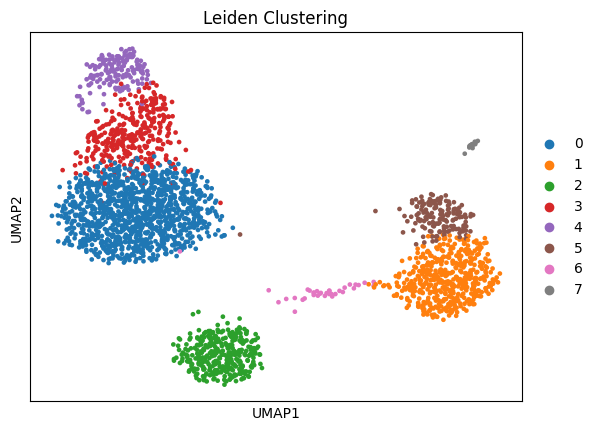

In [15]:
import scanpy as sc

# Load the example dataset
adata = sc.datasets.pbmc3k_processed()

# Calculate the neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, use_rep='X_pca')

# Compute UMAP for visualization
sc.tl.umap(adata)

# Perform clustering
sc.tl.leiden(adata)

# Infer the trajectory (pseudotime)
sc.tl.diffmap(adata)
sc.tl.dpt(adata)

# Visualize the results
sc.pl.umap(adata, color=['leiden', 'dpt_pseudotime'], title=['Leiden Clustering', 'Diffusion Pseudotime'])

# scanpy:3
* note that this prompt is not detailed enough. ranking genes based on what scores? we should carefully design prompts. 
* it works!
---
* new report
* plans: load data -> highly_variable_genes -> vis
* error: no error
---
* old report
* plans: load data -> preprocessing -> highly_variable_genes -> pca -> leiden clustering -> vis
* error: original report says "TypeError: putmask: first argument must be an array". But after checking original codes, I suspect the problem is "log1p has negative values as input", similar to scanpy:1.

## results

In [4]:
print(query_dict['scanpy:3'])

Provide the python code for plotting the ranking of genes with the API only from Scanpy. Apply it to the built-in pbmc3k processed dataset.


In [16]:
print(response_dict['scanpy:3'])

Below is a Python code example to load the pbmc3k dataset, process it using Scanpy, and then plot rankings of genes based on their scores using Scanpy's plotting function. This example assumes that you have installed Scanpy; if not, you can install it using `pip install scanpy`.

Here's the step-by-step guide with code:

1. **Import necessary libraries**:
   ```python
   import scanpy as sc
   ```

2. **Load PBMC3k dataset**:
   ```python
   adata = sc.datasets.pbmc3k_processed()
   ```

3. **Compute the ranking of genes**:
   To plot the gene rankings, we typically consider different metrics. Here, we will use a simple method to score genes, such as using the highly variable genes as an example. If you've already processed the data and identified highly variable genes, you can skip recomputation.

   First, ensure the highly variable genes are identified:
   ```python
   sc.pp.highly_variable_genes(adata, n_top_genes=20)  # You can adjust the number of top genes
   ```

4. **Plotting 

In [17]:
print(code_dict['scanpy:3'])

   import scanpy as sc
   adata = sc.datasets.pbmc3k_processed()
   sc.pp.highly_variable_genes(adata, n_top_genes=20)  # You can adjust the number of top genes
   sc.tl.rank_genes_groups(adata, 'louvain', method='t-test')
   sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)  # Adjust n_genes as needed
import scanpy as sc

# Load preprocessed PBMC3k dataset
adata = sc.datasets.pbmc3k_processed()

# Check and compute highly variable genes if needed
if not hasattr(adata.var, 'highly_variable'):
    sc.pp.highly_variable_genes(adata, n_top_genes=20)

# Perform differential gene expression ranking if not already done
if 'rank_genes_groups' not in adata.uns:
    sc.tl.rank_genes_groups(adata, 'louvain', method='t-test')

# Plot ranking of genes
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)


## try 1

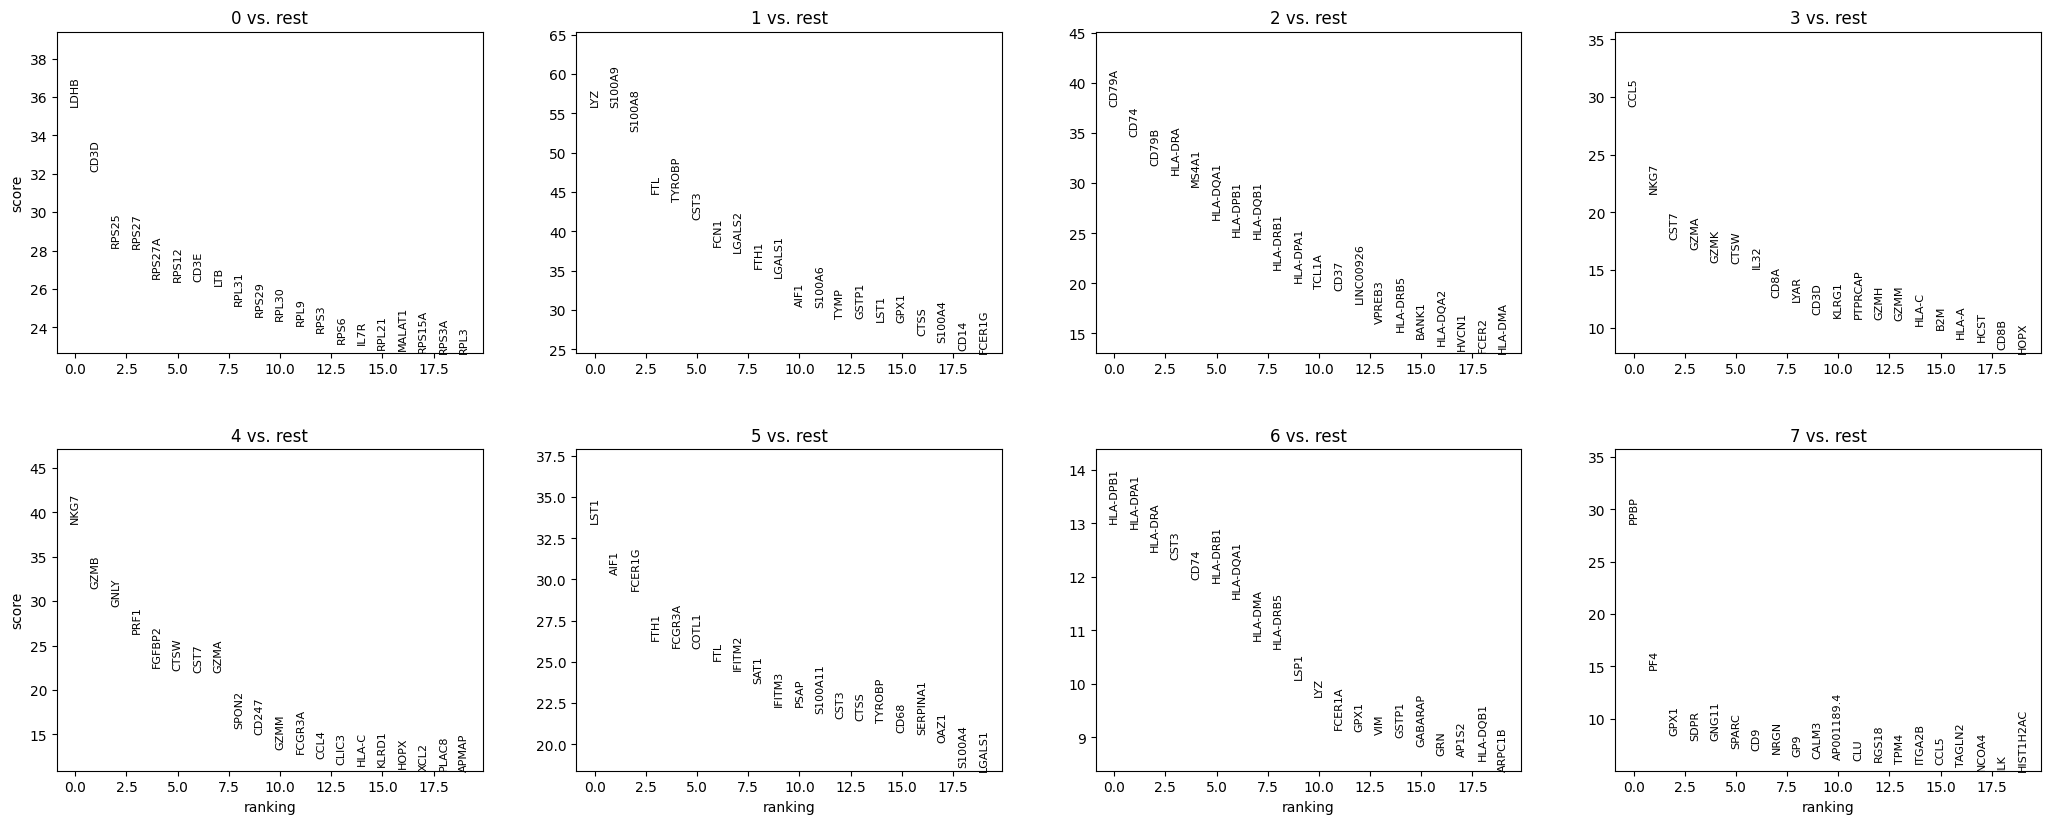

In [18]:
import scanpy as sc

# Load preprocessed PBMC3k dataset
adata = sc.datasets.pbmc3k_processed()

# Check and compute highly variable genes if needed
if not hasattr(adata.var, 'highly_variable'):
    sc.pp.highly_variable_genes(adata, n_top_genes=20)

# Perform differential gene expression ranking if not already done
if 'rank_genes_groups' not in adata.uns:
    sc.tl.rank_genes_groups(adata, 'louvain', method='t-test')

# Plot ranking of genes
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

# scanpy:4
* it works!
---
* new report
* plans: load data -> select genes -> vis
    * risks: if users' own datasets, bioma don't know which genes are included (that is, .var_names), we need users to specify selected genes or let bioma access .var_names list.
* error: no error
---
* old report:
* plans: load data -> preprocess -> select genes -> violin
* error: KeyError: "Could not find keys '['CD34']' in columns ofadata.obsor in adata.raw.var_names.". Because it didn't know which attribute is indeed exist in the adata object. This is exactly the risks reported above.
* error2: although not being reported, log1p is conducted after loading pbmc3k_processed data. Like scanpy:1, this process creates nan problem.

## results

In [5]:
print(query_dict['scanpy:4'])

Provide the python code for visualizing the genes expression values through violin figure with the API only from Scanpy. Apply it to the built-in pbmc3k processed dataset.


In [20]:
print(response_dict['scanpy:4'])

Below is an example Python script that uses Scanpy to visualize gene expression values using a violin plot for the built-in `pbmc3k_processed` single-cell RNA-seq dataset. The script covers the necessary steps including loading the data, preprocessing, and generating violin plots for selected genes:

```python
import scanpy as sc

# Load the example pbmc3k dataset
adata = sc.datasets.pbmc3k_processed()

# Optional: Normalize data (already preprocessed, but here as a reference)
# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)

# Select a list of genes you are interested in
genes_to_plot = ['IL7R', 'CD3D', 'CD79A', 'MS4A1']

# Create violin plots for the selected genes
sc.pl.violin(adata, keys=genes_to_plot, groupby='louvain')

# Show the plot
sc.pl.show()
```

Key steps in this script:
1. **Loading Data**: It loads the `pbmc3k_processed` data that comes with Scanpy which is already preprocessed and clustered.
2. **Visualization**: The `sc.pl.violin` function is used t

In [21]:
print(code_dict['scanpy:4'])

import scanpy as sc

# Load the example pbmc3k dataset
adata = sc.datasets.pbmc3k_processed()

# Optional: Normalize data (already preprocessed, but here as a reference)
# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)

# Select a list of genes you are interested in
genes_to_plot = ['IL7R', 'CD3D', 'CD79A', 'MS4A1']

# Create violin plots for the selected genes
sc.pl.violin(adata, keys=genes_to_plot, groupby='louvain')

# Show the plot
sc.pl.show()


## try 1
* although with bugs, can basically work

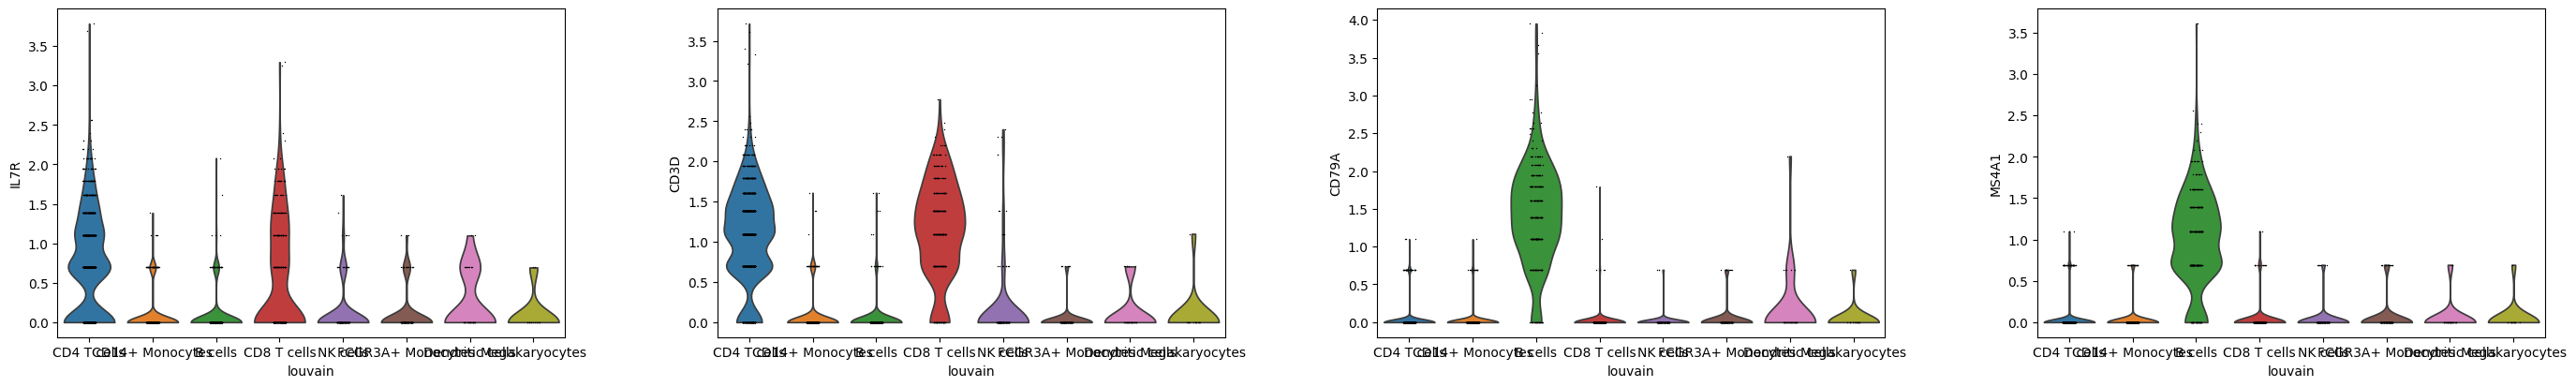

AttributeError: module 'scanpy.plotting' has no attribute 'show'

In [6]:
import scanpy as sc

# Load the example pbmc3k dataset
adata = sc.datasets.pbmc3k_processed()

# Optional: Normalize data (already preprocessed, but here as a reference)
# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)

# Select a list of genes you are interested in
genes_to_plot = ['IL7R', 'CD3D', 'CD79A', 'MS4A1']

# Create violin plots for the selected genes
sc.pl.violin(adata, keys=genes_to_plot, groupby='louvain')

# Show the plot
sc.pl.show()

# scanpy:6 (5 has no prompt)
* check try 3
---
* new report
* plans: 

## results

In [14]:
print(query_dict['scanpy:6'])

Provide the python code for visualizing the genes expression values through heatmap with the API only from Scanpy. Apply it to the built-in pbmc3k processed dataset.


In [24]:
print(response_dict['scanpy:6'])

Below is the Python code that illustrates how to visualize gene expression values using a heatmap from the pbmc3k processed dataset using the Scanpy library. Ensure you have Scanpy installed in your Python environment. If it's not installed, you can install it using `pip install scanpy`.

Here's a step-by-step process and the corresponding Python code:

1. **Import Necessary Libraries**:
   First, you need to import Scanpy and other necessary libraries.

2. **Load the Dataset**:
   Load the pbmc3k dataset directly using Scanpy's datasets module.

3. **Preprocess the Data**:
   Perform necessary preprocessing steps such as normalization and identification of highly variable genes.

4. **Run PCA and Clustering**:
   Calculate principal components and perform clustering to explore the data structure.

5. **Generate a Heatmap**:
   Select genes of interest (or use the top ranked genes from the variable genes) and create a heatmap to visualize their expression patterns across different clus

In [25]:
print(code_dict['scanpy:6'])

import scanpy as sc

# Step 1: Load the PBMC 3k dataset
adata = sc.datasets.pbmc3k_processed()

# Step 2: Preprocess the dataset (if not already preprocessed)
# Normalize (this dataset is already normalized and log-transformed as per Scanpy's dataset description)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Identify highly variable genes (already done in pbmc3k_processed, but here as a template)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

# Step 3: PCA
sc.tl.pca(adata, svd_solver='arpack')

# Step 4: Compute the neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

# Step 5: Run clustering (e.g., Louvain)
sc.tl.louvain(adata)

# Step 6: Run UMAP (for visualization purposes)
sc.tl.umap(adata)

# Step 7: Find marker genes
sc.tl.rank_genes_groups(adata, 'louvain', method='t-test')

# Step 8: Plotting Heatmap of the top 20 marker genes per cluster
sc.pl.heatmap(adata, var_names=adata.uns['rank_genes_groups']['names'][0:20], groupby='louvain', 

## try 1

In [26]:
import scanpy as sc

# Step 1: Load the PBMC 3k dataset
adata = sc.datasets.pbmc3k_processed()

# Step 2: Preprocess the dataset (if not already preprocessed)
# Normalize (this dataset is already normalized and log-transformed as per Scanpy's dataset description)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Identify highly variable genes (already done in pbmc3k_processed, but here as a template)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

# Step 3: PCA
sc.tl.pca(adata, svd_solver='arpack')

# Step 4: Compute the neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

# Step 5: Run clustering (e.g., Louvain)
sc.tl.louvain(adata)

# Step 6: Run UMAP (for visualization purposes)
sc.tl.umap(adata)

# Step 7: Find marker genes
sc.tl.rank_genes_groups(adata, 'louvain', method='t-test')

# Step 8: Plotting Heatmap of the top 20 marker genes per cluster
sc.pl.heatmap(adata, var_names=adata.uns['rank_genes_groups']['names'][0:20], groupby='louvain', cmap='viridis', dendrogram=True)

# Additional: Plot UMAP to visualize the clusters
sc.pl.umap(adata, color='louvain', title='UMAP projection of the PBMC3k dataset', frameon=False)

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:383: RuntimeWarning: invalid value encountered in log1p
  np.log1p(X, out=X)


TypeError: putmask: first argument must be an array

## try 2

In [27]:
import scanpy as sc

# Step 1: Load the PBMC 3k dataset
adata = sc.datasets.pbmc3k_processed()

# Step 2: Preprocess the dataset (if not already preprocessed)
# Normalize (this dataset is already normalized and log-transformed as per Scanpy's dataset description)
# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)

# Identify highly variable genes (already done in pbmc3k_processed, but here as a template)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

# Step 3: PCA
sc.tl.pca(adata, svd_solver='arpack')

# Step 4: Compute the neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

# Step 5: Run clustering (e.g., Louvain)
sc.tl.louvain(adata)

# Step 6: Run UMAP (for visualization purposes)
sc.tl.umap(adata)

# Step 7: Find marker genes
sc.tl.rank_genes_groups(adata, 'louvain', method='t-test')

# Step 8: Plotting Heatmap of the top 20 marker genes per cluster
sc.pl.heatmap(adata, var_names=adata.uns['rank_genes_groups']['names'][0:20], groupby='louvain', cmap='viridis', dendrogram=True)

# Additional: Plot UMAP to visualize the clusters
sc.pl.umap(adata, color='louvain', title='UMAP projection of the PBMC3k dataset', frameon=False)

ModuleNotFoundError: No module named 'louvain'

## try 3
* the problem of try 2 is resolved after pip install louvain, but still not work

In [32]:
import scanpy as sc

# Step 1: Load the PBMC 3k dataset
adata = sc.datasets.pbmc3k_processed()

# Step 2: Preprocess the dataset (if not already preprocessed)
# Normalize (this dataset is already normalized and log-transformed as per Scanpy's dataset description)
# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)

# Identify highly variable genes (already done in pbmc3k_processed, but here as a template)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

# Step 3: PCA
sc.tl.pca(adata, svd_solver='arpack')

# Step 4: Compute the neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

# Step 5: Run clustering (e.g., Louvain)
sc.tl.louvain(adata)

# Step 6: Run UMAP (for visualization purposes)
sc.tl.umap(adata)

# Step 7: Find marker genes
sc.tl.rank_genes_groups(adata, 'louvain', method='t-test')

# Step 8: Plotting Heatmap of the top 20 marker genes per cluster
sc.pl.heatmap(adata, var_names=adata.uns['rank_genes_groups']['names'][0:20], groupby='louvain', cmap='viridis', dendrogram=True)

# Additional: Plot UMAP to visualize the clusters
sc.pl.umap(adata, color='louvain', title='UMAP projection of the PBMC3k dataset', frameon=False)

TypeError: unhashable type: 'writeable void-scalar'

# scanpy:7
* check try 2

In [33]:
print(response_dict['scanpy:7'])

To compute Moran's I in Python using Scanpy, you first need to have the Scanpy library installed. Scanpy is a popular library used for analyzing and visualizing single-cell RNA sequencing data. The following steps guide you through installing Scanpy (if necessary), loading the pbmc3k dataset, preprocessing it, and then computing Moran’s I.

Before we go to Python code, ensure you have all the required packages installed. You can install Scanpy using pip or conda:
```bash
pip install scanpy
```

Here's how to use Scanpy to compute Moran's I for the pbmc3k dataset:

1. **Import Libraries and Load Data**:
   Load the necessary libraries and the example dataset from Scanpy.

2. **Preprocess the Data**: 
   Filter the cells and genes, normalize the counts, and scale the data.

3. **Compute Moran’s I**:
   Use spatial statistics module `scanpy.metrics` which includes the function to compute Moran's I.

Here's a complete example:

```python
import scanpy as sc

def main():
    # Load an examp

In [34]:
print(code_dict['scanpy:7'])

import scanpy as sc

def main():
    # Load an example dataset
    adata = sc.datasets.pbmc3k_processed()
    
    # Normally preprocessing would be here, but pbmc3k_processed is already preprocessed
    # Ensuring principal component analysis is done
    if 'X_pca' not in adata.obsm.keys():
        sc.tl.pca(adata)
    
    # Compute a neighborhood graph
    sc.pp.neighbors(adata, n_neighbors=10, use_rep='X_pca')
    
    # Compute Moran's I for some genes - here using example genes
    # Select a few genes for demonstration
    example_genes = adata.var_names[:5]
    
    # Compute Moran's I for these genes
    morans_i_results = {}
    for gene in example_genes:
        adata.obs[gene] = adata[:, gene].X
        morans_i = sc.metrics.morans_i(adata, var_names=gene)
        morans_i_results[gene] = morans_i

    # Print the results
    for gene, result in morans_i_results.items():
        print(f"Moran's I for {gene}: {result['I']:.4f}")

if __name__ == "__main__":
    main()


## try 1

In [36]:
import scanpy as sc

# Load an example dataset
adata = sc.datasets.pbmc3k_processed()

# Normally preprocessing would be here, but pbmc3k_processed is already preprocessed
# Ensuring principal component analysis is done
if 'X_pca' not in adata.obsm.keys():
    sc.tl.pca(adata)

# Compute a neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, use_rep='X_pca')

# Compute Moran's I for some genes - here using example genes
# Select a few genes for demonstration
example_genes = adata.var_names[:5]

# Compute Moran's I for these genes
morans_i_results = {}
for gene in example_genes:
    adata.obs[gene] = adata[:, gene].X
    morans_i = sc.metrics.morans_i(adata, var_names=gene)
    morans_i_results[gene] = morans_i

# Print the results
for gene, result in morans_i_results.items():
    print(f"Moran's I for {gene}: {result['I']:.4f}")


ValueError: Data must be 1-dimensional, got ndarray of shape (2638, 1) instead

## try 2

In [39]:
import scanpy as sc

# Load an example dataset
adata = sc.datasets.pbmc3k_processed()

# Normally preprocessing would be here, but pbmc3k_processed is already preprocessed
# Ensuring principal component analysis is done
if 'X_pca' not in adata.obsm.keys():
    sc.tl.pca(adata)

# Compute a neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, use_rep='X_pca')

# Compute Moran's I for some genes - here using example genes
# Select a few genes for demonstration
example_genes = adata.var_names[:5]

# Compute Moran's I for these genes
morans_i_results = {}
for gene in example_genes:
    adata.obs[gene] = adata[:, gene].X.flatten()
    morans_i = sc.metrics.morans_i(adata, var_names=gene)
    morans_i_results[gene] = morans_i

# Print the results
for gene, result in morans_i_results.items():
    print(f"Moran's I for {gene}: {result['I']:.4f}")


TypeError: morans_i() got an unexpected keyword argument 'var_names'

# scanpy:8
* try 2 works!

In [40]:
print(response_dict['scanpy:8'])

To plot the density of cells in UMAP embeddings using Scanpy for the built-in `pbmc3k` dataset, follow these steps. We'll load the dataset, preprocess the data, run a UMAP for dimensionality reduction, and then plot the density.

First, you will need to install Scanpy if it's not already installed. You can install it using pip:

```bash
pip install scanpy
```

Here's a Python script to perform these actions:

```python
import scanpy as sc

# Load PBMC 3k dataset
adata = sc.datasets.pbmc3k_processed()

# Check if UMAP is already computed
if 'X_umap' not in adata.obsm.keys():
    sc.tl.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)

# Plot UMAP with density estimation
sc.pl.umap(adata, color='louvain', use_raw=False, size=30, density=True)

```

### Explanation:

1. **Load Data**: The PBMC 3k dataset is loaded using `sc.datasets.pbmc3k_processed()`. It contains preprocessed single-cell RNA-sequencing data.

2. **Dimensionality Reduction**:
   - It checks if UMAP embeddings a

In [41]:
print(code_dict['scanpy:8'])

import scanpy as sc

# Load PBMC 3k dataset
adata = sc.datasets.pbmc3k_processed()

# Check if UMAP is already computed
if 'X_umap' not in adata.obsm.keys():
    sc.tl.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)

# Plot UMAP with density estimation
sc.pl.umap(adata, color='louvain', use_raw=False, size=30, density=True)



## try 1

AttributeError: PathCollection.set() got an unexpected keyword argument 'density'

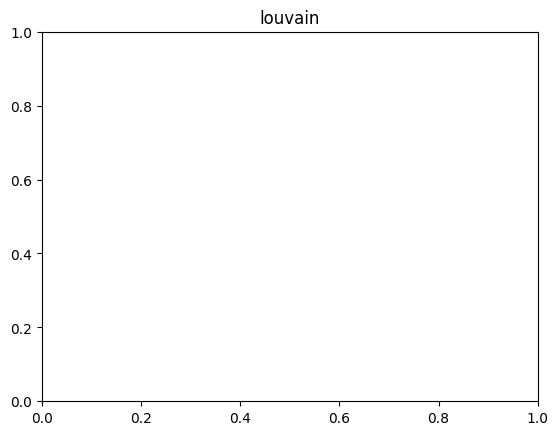

In [42]:
import scanpy as sc

# Load PBMC 3k dataset
adata = sc.datasets.pbmc3k_processed()

# Check if UMAP is already computed
if 'X_umap' not in adata.obsm.keys():
    sc.tl.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)

# Plot UMAP with density estimation
sc.pl.umap(adata, color='louvain', use_raw=False, size=30, density=True)

## try 2

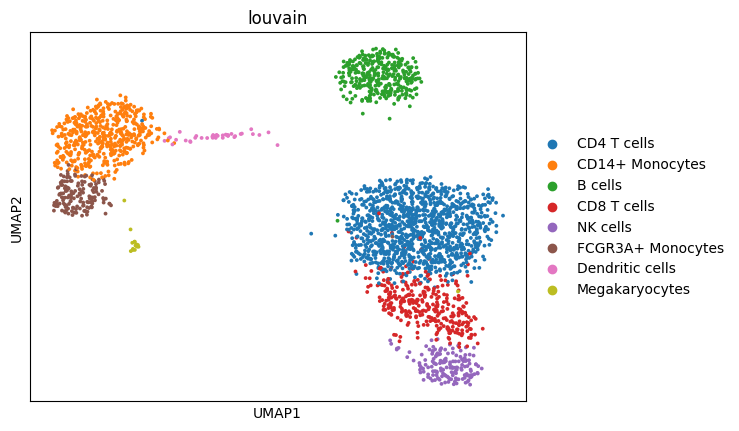

In [43]:
import scanpy as sc

# Load PBMC 3k dataset
adata = sc.datasets.pbmc3k_processed()

# Check if UMAP is already computed
if 'X_umap' not in adata.obsm.keys():
    sc.tl.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)

# Plot UMAP with density estimation
sc.pl.umap(adata, color='louvain', use_raw=False, size=30)

# scanpy:9
* try 2 works!

In [44]:
print(response_dict['scanpy:9'])

To create a hierarchically clustered heatmap using only the API from Scanpy on the pbmc3k processed dataset, follow these steps in Python. You need to install Scanpy and its dependencies if you haven't done so already. Here’s how to do it, along with the code to load the dataset, preprocess it, compute the necessary statistics, and plot the heatmap:

1. **Installation**: If not already installed, install Scanpy using pip.

   ```bash
   pip install scanpy
   ```

2. **Code**:
   ```python
   import scanpy as sc

   # Load the example pbmc3k dataset
   adata = sc.datasets.pbmc3k_processed()

   # We'll visualize the top 10 most variable genes for simplicity
   # First, compute the variable genes if they are not already present
   sc.pp.highly_variable_genes(adata, n_top_genes=10)

   # Extract the highly variable genes' data
   adata_var = adata[:, adata.var['highly_variable']]

   # Perform clustering - this is required for hierarchical clustering heatmaps
   sc.tl.dendrogram(adata_var

In [45]:
print(code_dict['scanpy:9'])

   import scanpy as sc

   # Load the example pbmc3k dataset
   adata = sc.datasets.pbmc3k_processed()

   # We'll visualize the top 10 most variable genes for simplicity
   # First, compute the variable genes if they are not already present
   sc.pp.highly_variable_genes(adata, n_top_genes=10)

   # Extract the highly variable genes' data
   adata_var = adata[:, adata.var['highly_variable']]

   # Perform clustering - this is required for hierarchical clustering heatmaps
   sc.tl.dendrogram(adata_var, n_pcs=20)

   # Plot the heatmap
   sc.pl.heatmap(adata_var, var_names=adata_var.var_names,
                 groupby='louvain', dendrogram=True)


## try 1

In [46]:
import scanpy as sc

# Load the example pbmc3k dataset
adata = sc.datasets.pbmc3k_processed()

# We'll visualize the top 10 most variable genes for simplicity
# First, compute the variable genes if they are not already present
sc.pp.highly_variable_genes(adata, n_top_genes=10)

# Extract the highly variable genes' data
adata_var = adata[:, adata.var['highly_variable']]

# Perform clustering - this is required for hierarchical clustering heatmaps
sc.tl.dendrogram(adata_var, n_pcs=20)

# Plot the heatmap
sc.pl.heatmap(adata_var, var_names=adata_var.var_names,
             groupby='louvain', dendrogram=True)

TypeError: dendrogram() missing 1 required positional argument: 'groupby'

## try 2

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/tools/_dendrogram.py:193: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = dat


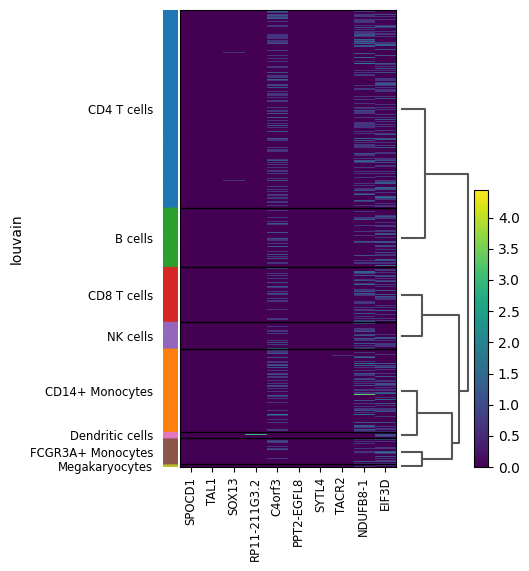

In [47]:
import scanpy as sc

# Load the example pbmc3k dataset
adata = sc.datasets.pbmc3k_processed()

# We'll visualize the top 10 most variable genes for simplicity
# First, compute the variable genes if they are not already present
sc.pp.highly_variable_genes(adata, n_top_genes=10)

# Extract the highly variable genes' data
adata_var = adata[:, adata.var['highly_variable']]

# Perform clustering - this is required for hierarchical clustering heatmaps
sc.tl.dendrogram(adata_var, groupby='louvain', n_pcs=20)

# Plot the heatmap
sc.pl.heatmap(adata_var, var_names=adata_var.var_names,
             groupby='louvain', dendrogram=True)

# scanpy:10
* try 1 works!

In [48]:
print(response_dict['scanpy:10'])

To visualize gene expression values using a dotplot from the Scanpy library, and applying it on the built-in `pbmc3k` dataset, follow these steps. This example assumes that you have Scanpy installed, and some basic preprocessing steps and clustering are done before visualizing the data. Here is the complete code that you would need:

```python
import scanpy as sc

# Load the example dataset
adata = sc.datasets.pbmc3k_processed()

# Basic preprocessing has already been done for pbmc3k_processed, 
# Normally you would run normalization and other preprocessing steps as required

# Calculate the average expression and the fraction of cells expressing each gene per cluster
sc.pp.neighbors(adata)  # Required for clustering
sc.tl.leiden(adata)     # Clustering algorithm
sc.tl.rank_genes_groups(adata, groupby='leiden', method='t-test')

# Subset the data to a few interesting genes; you can modify this list as needed
genes_of_interest = ['IL7R', 'CD3D', 'CD3E', 'CD3G', 'CD4', 'CD8A', 'LYZ', 'MS

In [49]:
print(code_dict['scanpy:10'])

import scanpy as sc

# Load the example dataset
adata = sc.datasets.pbmc3k_processed()

# Basic preprocessing has already been done for pbmc3k_processed, 
# Normally you would run normalization and other preprocessing steps as required

# Calculate the average expression and the fraction of cells expressing each gene per cluster
sc.pp.neighbors(adata)  # Required for clustering
sc.tl.leiden(adata)     # Clustering algorithm
sc.tl.rank_genes_groups(adata, groupby='leiden', method='t-test')

# Subset the data to a few interesting genes; you can modify this list as needed
genes_of_interest = ['IL7R', 'CD3D', 'CD3E', 'CD3G', 'CD4', 'CD8A', 'LYZ', 'MS4A1', 'CD14', 'CD19']

# Dotplot
sc.pl.dotplot(adata, genes_of_interest, groupby='leiden', dendrogram=True)


## try 1

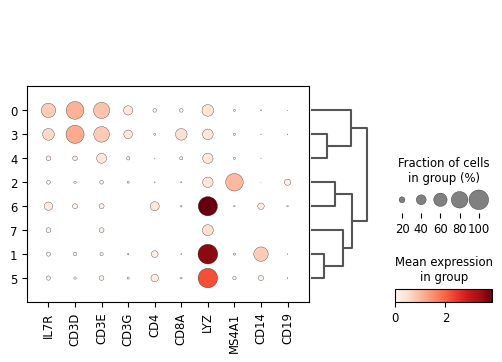

In [50]:
import scanpy as sc

# Load the example dataset
adata = sc.datasets.pbmc3k_processed()

# Basic preprocessing has already been done for pbmc3k_processed, 
# Normally you would run normalization and other preprocessing steps as required

# Calculate the average expression and the fraction of cells expressing each gene per cluster
sc.pp.neighbors(adata)  # Required for clustering
sc.tl.leiden(adata)     # Clustering algorithm
sc.tl.rank_genes_groups(adata, groupby='leiden', method='t-test')

# Subset the data to a few interesting genes; you can modify this list as needed
genes_of_interest = ['IL7R', 'CD3D', 'CD3E', 'CD3G', 'CD4', 'CD8A', 'LYZ', 'MS4A1', 'CD14', 'CD19']

# Dotplot
sc.pl.dotplot(adata, genes_of_interest, groupby='leiden', dendrogram=True)


# scanpy:11
* try 2 works with some tricks

In [51]:
print(response_dict['scanpy:11'])

To visualize gene expression using a tracks plot (or heatmap) for specific genes using Scanpy's API on the pbmc3k dataset, follow these steps. This includes loading the dataset, basic preprocessing, and finally, generating the plot. I'll walk you through the process using Python.

First, ensure you have the necessary libraries installed. If you haven't installed them yet, you can do so using `pip`:

```bash
pip install scanpy pandas matplotlib
```

Now, let's move on to the Python code. In this example, we'll select a few genes typically important in immunology (e.g., CD3D, CD14, and GNLY) to visualize their expression across cells.

```python
import scanpy as sc

# Load the example dataset
adata = sc.datasets.pbmc3k_processed()

# Basic preprocessing steps have already been performed on this dataset
# Typically, you might need to run sc.pp.normalize_per_cell and sc.pp.log1p

# Select genes to visualize
genes = ['CD3D', 'CD14', 'GNLY']

# Filtering data to include only the specified ge

In [52]:
print(code_dict['scanpy:11'])

import scanpy as sc

# Load the example dataset
adata = sc.datasets.pbmc3k_processed()

# Basic preprocessing steps have already been performed on this dataset
# Typically, you might need to run sc.pp.normalize_per_cell and sc.pp.log1p

# Select genes to visualize
genes = ['CD3D', 'CD14', 'GNLY']

# Filtering data to include only the specified genes
adata_subset = adata[:, genes]

# Generate the tracks plot
sc.pl.tracksplot(adata_subset, groupby='louvain', dendrogram=True, figsize=(10, 5), show_gene_labels=True)

# Show the plot
import matplotlib.pyplot as plt
plt.show()


## try 1

In [53]:
import scanpy as sc

# Load the example dataset
adata = sc.datasets.pbmc3k_processed()

# Basic preprocessing steps have already been performed on this dataset
# Typically, you might need to run sc.pp.normalize_per_cell and sc.pp.log1p

# Select genes to visualize
genes = ['CD3D', 'CD14', 'GNLY']

# Filtering data to include only the specified genes
adata_subset = adata[:, genes]

# Generate the tracks plot
sc.pl.tracksplot(adata_subset, groupby='louvain', dendrogram=True, figsize=(10, 5), show_gene_labels=True)

# Show the plot
import matplotlib.pyplot as plt
plt.show()

KeyError: "Values ['CD3D', 'CD14'], from ['CD3D', 'CD14', 'GNLY'], are not valid obs/ var names or indices."

## try 2: what if gpt knows var_names?

In [58]:
adata.var_names

Index(['TNFRSF4', 'CPSF3L', 'ATAD3C', 'C1orf86', 'RER1', 'TNFRSF25', 'TNFRSF9',
       'CTNNBIP1', 'SRM', 'UBIAD1',
       ...
       'DSCR3', 'BRWD1', 'BACE2', 'SIK1', 'C21orf33', 'ICOSLG', 'SUMO3',
       'SLC19A1', 'S100B', 'PRMT2'],
      dtype='object', name='index', length=1838)

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/tools/_dendrogram.py:193: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = dat


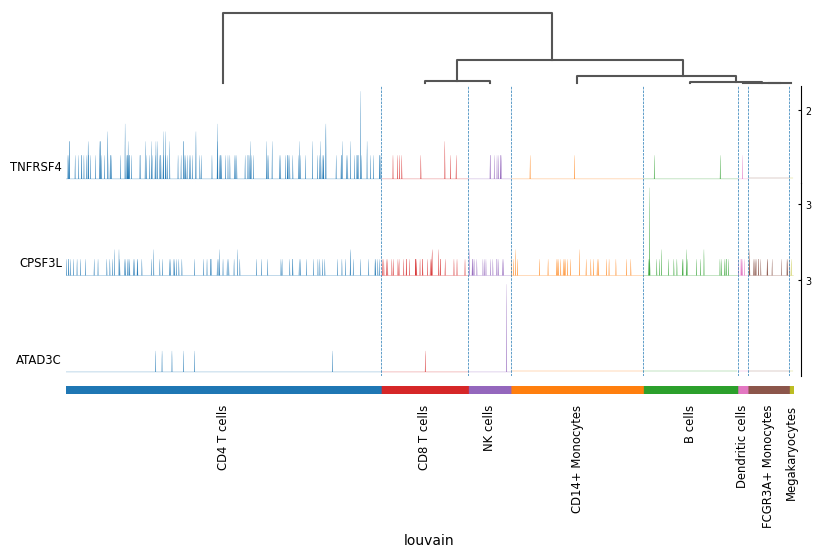

In [59]:
import scanpy as sc

# Load the example dataset
adata = sc.datasets.pbmc3k_processed()

# Basic preprocessing steps have already been performed on this dataset
# Typically, you might need to run sc.pp.normalize_per_cell and sc.pp.log1p

# Select genes to visualize
# Jiahang (1): given that gpt has the information of var_names
genes = ['TNFRSF4', 'CPSF3L', 'ATAD3C']

# Filtering data to include only the specified genes
adata_subset = adata[:, genes]

# Generate the tracks plot
# Jiahang: given (1), we presume that gpt can access adata.var_names, thus it knows arg "var_names" should be "genes", 
# Jiahang: which is a subset of adata.var_names
sc.pl.tracksplot(adata_subset, var_names=genes, groupby='louvain', dendrogram=True, figsize=(10, 5), show_gene_labels=True)

# Show the plot
import matplotlib.pyplot as plt
plt.show()

# ehrapy:1
* check try 1

In [62]:
print(response_dict['ehrapy:1'])

As of my last training data, Ehrapy primarily focuses on preprocessing and analysis of single-cell genomics data. It does not directly support survival analysis or specific clinical datasets like MIMIC. However, using Python for survival analysis typically involves libraries such as Lifelines, which is widely used for Kaplan-Meier analysis. To apply Kaplan-Meier Survival analysis to the MIMIC-II dataset, you would need to first process data using appropriate tools for clinical datasets, then use survival analysis tools.

Since the MIMIC-II dataset isn't directly supported by Ehrapy, you can consider using Pandas for data manipulation and Lifelines for the Kaplan-Meier analysis. Here's how you might approach the task using Python with appropriate libraries:

### Step 1: Install Necessary Libraries
You may need to install `pandas` and `lifelines`. If they are not installed, you can do so using pip:

```bash
pip install pandas lifelines
```

### Step 2: Load and Prepare Data
For this exam

In [63]:
print(code_dict['ehrapy:1'])

import pandas as pd
from lifelines import KaplanMeierFitter

# Assuming 'df' is your DataFrame with MIMIC-II data
# df = pd.read_csv('path_to_data.csv')  # Load your dataset accordingly

# Examples of columns names, adjust these according to your dataset's specific columns
time_column = 'time_to_event'
event_column = 'event_occurred'
# Create a Kaplan-Meier object
kmf = KaplanMeierFitter()

# Fit data
kmf.fit(df[time_column], event_observed=df[event_column])

# Plot the survival function
import matplotlib.pyplot as plt
kmf.plot_survival_function()
plt.title('Survival function using Kaplan-Meier Estimation')
plt.xlabel('Time')
plt.ylabel('Survival probability')
plt.show()


## try 1

In [64]:
import pandas as pd
from lifelines import KaplanMeierFitter

# Assuming 'df' is your DataFrame with MIMIC-II data
# df = pd.read_csv('path_to_data.csv')  # Load your dataset accordingly

# Examples of columns names, adjust these according to your dataset's specific columns
time_column = 'time_to_event'
event_column = 'event_occurred'
# Create a Kaplan-Meier object
kmf = KaplanMeierFitter()

# Fit data
kmf.fit(df[time_column], event_observed=df[event_column])

# Plot the survival function
import matplotlib.pyplot as plt
kmf.plot_survival_function()
plt.title('Survival function using Kaplan-Meier Estimation')
plt.xlabel('Time')
plt.ylabel('Survival probability')
plt.show()

NameError: name 'df' is not defined

# ehrapy:2
* check try 1

In [65]:
print(response_dict['ehrapy:2'])

To conduct a basic analysis of causal inference using Python and ehrapy, a library designed for efficient analysis of Electronic Health Records (EHR), we can outline a simple example. However, it's important to note a couple of limitations upfront:

1. As of my last update, ehrapy primarily focuses on processing and managing EHR data, particularly dealing with privacy and computational efficiency considerations. It does not directly offer tools for causal inference.

2. Causal inference typically requires specific statistical or machine learning methods like propensity score matching, instrumental variables, or others which ehrapy (as of the last knowledge update) does not support.

3. Conducting causal inference usually requires significant domain knowledge and careful statistical analysis.

Given these constraints, our approach will be to first demonstrate how to use ehrapy to load and manage data, and then switch to a standard Python library for causal inference (like `causalml` or 

In [66]:
print(code_dict['ehrapy:2'])

import ehrapy as ep

# Assuming the data is in 'mimic_data.csv'
# Note: Update the path to where you have stored your dataset.
data_path = 'path_to_mimic_data/mimic_data.csv'
data = ep.io.read_csv(data_path, index_column=None)
# Assuming 'treatment' is our treatment variable and 'outcome' is what we're measuring
df = data[data.columns[:]]  # Select relevant columns if needed

# For illustration, using pandas to manage missing data
df = df.dropna(subset=['treatment', 'outcome'])
from causalml.inference.meta import BaseXRegressor
from sklearn.ensemble import RandomForestRegressor

# Convert treatment and control to binary for simplicity
df['treatment'] = df['treatment'].apply(lambda x: 1 if x == 'treated' else 0)

# Creating X and y for causal inference model
X = df.drop('outcome', axis=1)
y = df['outcome']

# Base learner
learner = BaseXRegressor(RandomForestRegressor())

# Estimate the causal effect and confidence intervals
ate, ate_lb, ate_ub = learner.estimate_ate(X=X, treatment=df['

## try 1
- [ ] notes: At first when trying following example after finishing above examples, "import ehrapy as ep" failed. After re-starting the kernel, this line works. It could be because some packages imported before affect ehrapy import, or some environments conflicts. In other words, to rigorously test all examples, it's better to test them in different environment (docker) rather than in a single notebook to avoid errors resulted from env or packages conflicts.
    - one another thing: snapatac2 and scvi-tool have confilicted version requirement of anndata.

In [2]:
import ehrapy as ep

# Assuming the data is in 'mimic_data.csv'
# Note: Update the path to where you have stored your dataset.
data_path = 'path_to_mimic_data/mimic_data.csv'
data = ep.io.read_csv(data_path, index_column=None)
# Assuming 'treatment' is our treatment variable and 'outcome' is what we're measuring
df = data[data.columns[:]]  # Select relevant columns if needed

# For illustration, using pandas to manage missing data
df = df.dropna(subset=['treatment', 'outcome'])
from causalml.inference.meta import BaseXRegressor
from sklearn.ensemble import RandomForestRegressor

# Convert treatment and control to binary for simplicity
df['treatment'] = df['treatment'].apply(lambda x: 1 if x == 'treated' else 0)

# Creating X and y for causal inference model
X = df.drop('outcome', axis=1)
y = df['outcome']

# Base learner
learner = BaseXRegressor(RandomForestRegressor())

# Estimate the causal effect and confidence intervals
ate, ate_lb, ate_ub = learner.estimate_ate(X=X, treatment=df['treatment'], y=y)
print(f"Average Treatment Effect: {ate}, Lower Bound: {ate_lb}, Upper Bound: {ate_ub}")

ValueError: File or directory path_to_mimic_data/mimic_data.csv does not exist and no backup_url was provided.
Please provide a backup_url or check whether path is spelled correctly.

# ehrapy:3
* check try 1. it seems that gpt4 lacks a lot of information of ehrapy needed by prompt.

In [5]:
print(response_dict['ehrapy:3'])

To compute the neighborhood graph on data using only Ehrapy's API and applying it to the built-in heart failure dataset, you can take the following steps. As of my last update, Ehrapy primarily focuses on preprocessing and managing single-cell RNA sequencing data. It may not directly support complex graph operations typically associated with packages like `scanpy` or `scikit-learn`. However, I can guide you through a typical process using Ehrapy.

Firstly, ensure you have Ehrapy installed. If not, you can install it using pip:

```bash
pip install ehrapy
```

Here’s how you can load the heart failure dataset and perform basic operations assuming that Ehrapy supports similar functionalities as scanpy but adjusted to clinical data:

```python
import ehrapy as ep

# Load example data
adata = ep.datasets.heart_failure()  # This function is hypothetical as Ehrapy may not directly provide this

# Generally, in scRNA-seq analysis with Scanpy, after initial preprocessing, 
# one would compute 

In [6]:
print(code_dict['ehrapy:3'])

import ehrapy as ep

# Load example data
adata = ep.datasets.heart_failure()  # This function is hypothetical as Ehrapy may not directly provide this

# Generally, in scRNA-seq analysis with Scanpy, after initial preprocessing, 
# one would compute the neighborhood graph as follows:
# sc.pp.neighbors(adata)
# However, since Ehrapy is more tailored towards clinical and EHR data rather than scRNA-seq, 
# it may not directly support such functional calls.

# We can simulate an approach that would be somewhat equivalent in a clinical dataset environment
# First, ensure the data is appropriately preprocessed:
# Normalizing or scaling data
adata_scaled = ep.pp.scale(adata, max_value=10)

# Since direct graph computation might not be supported, we would typically need to
# either adapt from Scanpy, scikit-learn or another package for detailed graph-based analysis:
# For instance, using PCA to reduce dimensions before computing a graph could be a start.
adata_pca = ep.tl.pca(adata_scaled, n_co

## try 1

In [8]:
import ehrapy as ep

# Load example data
adata = ep.datasets.heart_failure()  # This function is hypothetical as Ehrapy may not directly provide this

# Generally, in scRNA-seq analysis with Scanpy, after initial preprocessing, 
# one would compute the neighborhood graph as follows:
# sc.pp.neighbors(adata)
# However, since Ehrapy is more tailored towards clinical and EHR data rather than scRNA-seq, 
# it may not directly support such functional calls.

# We can simulate an approach that would be somewhat equivalent in a clinical dataset environment
# First, ensure the data is appropriately preprocessed:
# Normalizing or scaling data
adata_scaled = ep.pp.scale(adata, max_value=10)

# Since direct graph computation might not be supported, we would typically need to
# either adapt from Scanpy, scikit-learn or another package for detailed graph-based analysis:
# For instance, using PCA to reduce dimensions before computing a graph could be a start.
adata_pca = ep.tl.pca(adata_scaled, n_comps=10)  # Hypothetically reducing dimensions

# As Ehrapy might not support direct neighbor graphs, here is how you might do it with scanpy:
# import scanpy as sc
# sc.pp.neighbors(adata_pca)

# Since I'm limited to using Ehrapy, and if it lacks the direct graph computation feature,
# we can only prepare the data up to the point where it's generally used.
# For the exact graph computation, you would need to use other tools or manually implement it.

# Please check the latest documentation of Ehrapy for any updates on graph computation support.



AttributeError: module 'ehrapy' has no attribute 'datasets'

# ehrapy:4
* check try 1

In [9]:
print(response_dict['ehrapy:4'])

As requested, below is an example Python code that uses the `ehrapy` library to compute a neighborhood graph on the built-in dermatology dataset. Since your request specifically mentions using only Ehrapy API which is formerly known as Scanpy, please ensure that Ehrapy is properly installed in your Python environment and updated. If it's not, it can be installed using pip:

```bash
pip install ehrapy
```

Please follow this Python script to compute the neighborhood graph:

```python
import ehrapy as ep
import ehrapy.pp as pp
import ehrapy.tl as tl

# Load the dermatology dataset
adata = ep.datasets.dermatology()

# Optional: Preprocessing steps
# Normalize the data (this step might be necessary for your specific algorithm needs)
pp.normalize_total(adata)

# Log transform the data for a more normal-like distribution if necessary
pp.log1p(adata)

# Find Variable features (if PCA, tSNE or UMAP needs to be further applied)
pp.highly_variable_genes(adata, n_top_genes=2000, subset=True)

# C

In [10]:
print(code_dict['ehrapy:4'])

import ehrapy as ep
import ehrapy.pp as pp
import ehrapy.tl as tl

# Load the dermatology dataset
adata = ep.datasets.dermatology()

# Optional: Preprocessing steps
# Normalize the data (this step might be necessary for your specific algorithm needs)
pp.normalize_total(adata)

# Log transform the data for a more normal-like distribution if necessary
pp.log1p(adata)

# Find Variable features (if PCA, tSNE or UMAP needs to be further applied)
pp.highly_variable_genes(adata, n_top_genes=2000, subset=True)

# Compute the neighborhood graph
tl.pca(adata)  # Compute PCA to reduce dimensionality
tl.neighbors(adata)  # Compute neighborhood graph

# Print the AnnData object to observe its structure and the computed information
print(adata)

# Optionally, run UMAP, tSNE, clustering, etc.
tl.umap(adata)
tl.leiden(adata)  # clustering

# Plotting the results (optional)
import ehrapy.pl as pl

pl.umap(adata, color='leiden')

# Display the plot
import matplotlib.pyplot as plt
plt.show()


## try 1

In [2]:
import ehrapy as ep
import ehrapy.pp as pp
import ehrapy.tl as tl

# Load the dermatology dataset
adata = ep.datasets.dermatology()

# Optional: Preprocessing steps
# Normalize the data (this step might be necessary for your specific algorithm needs)
pp.normalize_total(adata)

# Log transform the data for a more normal-like distribution if necessary
pp.log1p(adata)

# Find Variable features (if PCA, tSNE or UMAP needs to be further applied)
pp.highly_variable_genes(adata, n_top_genes=2000, subset=True)

# Compute the neighborhood graph
tl.pca(adata)  # Compute PCA to reduce dimensionality
tl.neighbors(adata)  # Compute neighborhood graph

# Print the AnnData object to observe its structure and the computed information
print(adata)

# Optionally, run UMAP, tSNE, clustering, etc.
tl.umap(adata)
tl.leiden(adata)  # clustering

# Plotting the results (optional)
import ehrapy.pl as pl

pl.umap(adata, color='leiden')

# Display the plot
import matplotlib.pyplot as plt
plt.show()

ModuleNotFoundError: No module named 'ehrapy.pp'